In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from ptlpinns.models import model, train_PDE, transfer_wave

/home/jovyan/PTL-PINNs/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Problem setup

Nonlinear wave equation with cubic nonlinearity:
$$u_{tt} = c^2\,u_{xx} - \varepsilon\,u^3,
\quad u(x,0)=\sin\!\left(\frac{\pi x}{L}\right),
\quad u_t(x,0)=0,
\quad u(0,t)=u(L,t)=0,\quad c=1.$$

Epsilon sweep using the pretrained `Wave_linear` backbone.
$H$ is computed once; for each $\varepsilon$ the perturbation series is
evaluated up to $p_{\max}$ and the MAE at $p_{\max}$ is recorded against
a high-accuracy numerical (RK45) reference.

In [ ]:
L, T = 2, 5
x_span, t_span = (0, L), (0, T)

Nx, Nt = 50, 50
x, t, grid = train_PDE.generate_interior_tensor(
    IG=(Nx, Nt), x_span=(0, L), t_span=(0, T), require_grad=False,
)

c     = 1
p_max = 5
Polynomial = [[1, 3]]   # encodes  P(u) = u^3  (equation: u_tt = c^2 u_xx - eps*u^3)

epsilon_values = np.arange(0.05, 2.0, 0.10)

def ic_sin(inp):
    xv = inp[:, 0].unsqueeze(1)
    return torch.sin(torch.pi * xv / L)

def constant_function(constant):
    def f(inp):
        return constant * torch.ones_like(inp[:, 0].unsqueeze(1))
    return f

icD         = ic_sin
icN         = constant_function(0)
bcs_torch   = [constant_function(0), constant_function(0)]
forcing_torch = constant_function(0)

In [7]:
0.05 ** 5

3.125000000000001e-07

### Numerical solver (RK45)

In [3]:
def solution_wave(epsilons, c, polynomial, x_span, t_span, Nx, Nt,
                  u0, v0, forcing, bcs, method="RK45", atol=1e-10, rtol=1e-10):
    Numerical_solutions = np.zeros((len(epsilons), Nx, Nt))
    for i in range(len(epsilons)):
        xv = np.linspace(x_span[0], x_span[1], Nx)
        dx = xv[1] - xv[0]
        tv = np.linspace(t_span[0], t_span[1], Nt)

        def rhs(t, y):
            u = y[:Nx].copy()
            v = y[Nx:]
            u_xx = np.zeros_like(u)
            u[0]  = bcs[i][0](t) if callable(bcs[i][0]) else bcs[i][0]
            u[-1] = bcs[i][1](t) if callable(bcs[i][1]) else bcs[i][1]
            u_xx[1:-1] = (u[2:] - 2*u[1:-1] + u[:-2]) / dx**2
            u_xx[0]  = 0
            u_xx[-1] = 0
            du_dt = v
            dv_dt = c**2 * u_xx - epsilons[i] * polynomial[i](u) + forcing[i](xv, t)
            return np.concatenate([du_dt, dv_dt])

        y0 = np.concatenate([u0[i](xv), v0[i](xv)])
        sol = solve_ivp(rhs, t_span=t_span, y0=y0, t_eval=tv,
                        method=method, rtol=rtol, atol=atol)
        Numerical_solutions[i] = sol.y[:Nx, :]
    return Numerical_solutions

def u0_np(xv): return np.sin(np.pi * xv / L)
def v0_np(xv): return np.zeros_like(xv)
def left_bc(t): return 0.0
def right_bc(t): return 0.0
def poly_np(u): return u**3

### Load model and build $H$ (once)

In [4]:
name = "model_Wave_linear.pth"
path = "/home/jovyan/PTL-PINNs/ptlpinns/models/train/Wave_linear"

pinn = model.Multihead_model_PDE(k=9, bias=True)
pinn.load_state_dict(torch.load(f"{path}/{name}"))

bias = True
w_pde, w_bc, w_ic = 1, 10, 10
training_log = {
    "name": name, "bias": bias, "k": 9,
    "domain_info": {"L": L, "T": T},
    "Nx": Nx, "Nt": Nt,
    "w_pde": w_pde, "w_bc": w_bc, "w_ic": w_ic,
}

H_dict = transfer_wave.compute_H_dict(
    model=pinn, IG=(Nx, Nt), Nic=Nx, Nbc=Nt, bias=False,
    x_span=x_span, t_span=t_span, log=training_log, c=c,
)
_, _, _ = transfer_wave.compute_M(H_dict=H_dict, w_pde=w_pde, w_ic=w_ic, w_bc=w_bc)

input_grid = torch.cat((x.unsqueeze(1), t.unsqueeze(1)), dim=1)

Differentiating H w.r.t. x now...
Finished computing H2x.
Differentiating H w.r.t. t now...
Finished computing H2t
Differentiating H_ic w.r.t. t now...
Finished computing Ht_bc


### Epsilon sweep

In [5]:
sweep_maes = []

print(f"Running wave equation epsilon sweep  (c={c}, p_max={p_max}) ...")
for epsilon in epsilon_values:
    result_ref = solution_wave(
        [epsilon], c, [poly_np],
        x_span, t_span, Nx, Nt,
        [u0_np], [v0_np],
        [lambda xv, tv: np.zeros_like(xv)],
        [(left_bc, right_bc)],
    )[0]

    cumulative, _ = transfer_wave.compute_perturbation_solution_polynomial_orders(
        p_max, epsilon, forcing_torch,
        H_dict=H_dict, input=input_grid,
        training_log=training_log,
        Polynomial=Polynomial,
        boundary_functions=bcs_torch,
        ic_functionD=icD,
        ic_functionN=icN,
    )

    mae = float(np.mean(np.abs(cumulative[-1].reshape(Nx, Nt) - result_ref)))
    sweep_maes.append(mae)
    print(f"  ε={epsilon:.2f}  MAE@p={p_max}: {mae:.3e}")

print(f"done — {len(sweep_maes)} epsilon values")

Running wave equation epsilon sweep  (c=1, p_max=2) ...
  ε=0.05  MAE@p=2: 2.699e-04
  ε=0.15  MAE@p=2: 3.129e-04
  ε=0.25  MAE@p=2: 4.867e-04
  ε=0.35  MAE@p=2: 8.920e-04
  ε=0.45  MAE@p=2: 1.621e-03
  ε=0.55  MAE@p=2: 2.760e-03
  ε=0.65  MAE@p=2: 4.372e-03
  ε=0.75  MAE@p=2: 6.521e-03
  ε=0.85  MAE@p=2: 9.266e-03
  ε=0.95  MAE@p=2: 1.266e-02
  ε=1.05  MAE@p=2: 1.676e-02
  ε=1.15  MAE@p=2: 2.161e-02
  ε=1.25  MAE@p=2: 2.725e-02
  ε=1.35  MAE@p=2: 3.374e-02
  ε=1.45  MAE@p=2: 4.110e-02
  ε=1.55  MAE@p=2: 4.939e-02
  ε=1.65  MAE@p=2: 5.865e-02
  ε=1.75  MAE@p=2: 6.891e-02
  ε=1.85  MAE@p=2: 8.020e-02
  ε=1.95  MAE@p=2: 9.255e-02
done — 20 epsilon values


### MAE @ $p = p_{\max}$ vs $\varepsilon^{p_{\max}}$ — normalised comparison

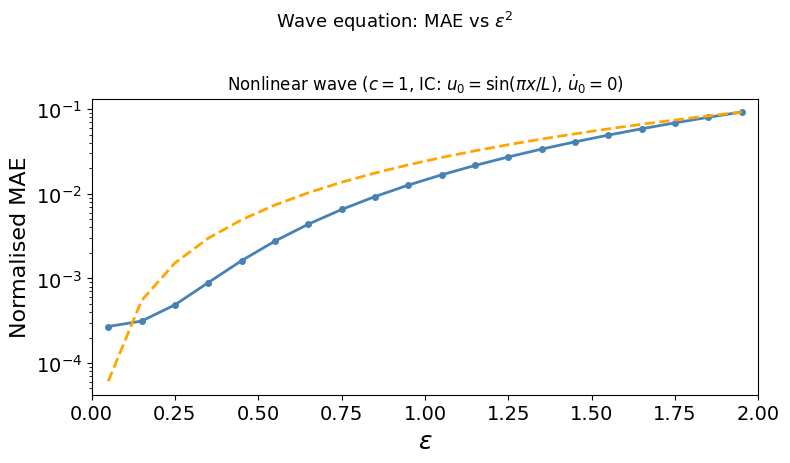

In [6]:
sweep_eps      = np.array(epsilon_values)
sweep_maes_arr = np.array(sweep_maes)
sweep_eps_ref  = sweep_eps ** p_max

mae_norm = sweep_maes_arr
ref_norm = sweep_eps_ref  * np.max(sweep_maes_arr) / np.max(sweep_eps_ref)

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(sweep_eps, mae_norm, "o-", linewidth=2, markersize=4,
        color="steelblue", label=rf"MAE @ $p={p_max}$")
ax.plot(sweep_eps, ref_norm, "--", linewidth=2,
        color="orange", label=rf"$\varepsilon^{{{p_max}}}$")

ax.set_title(
    rf"Nonlinear wave ($c={c}$, IC: $u_0=\sin(\pi x/L)$, $\dot{{u}}_0=0$)",
    fontsize=12,
)
ax.set_yscale("log")
ax.set_xlim(0, 2.0)
ax.tick_params(axis="both", labelsize=14)
ax.set_xlabel(r"$\varepsilon$", fontsize=18)
ax.set_ylabel("Normalised MAE", fontsize=16)

fig.suptitle(
    rf"Wave equation: MAE vs $\varepsilon^{{{p_max}}}$",
    fontsize=13, y=1.02,
)
plt.tight_layout()
plt.show()